# Simple Linear regression - Implementation

- Dataset: [Salary Dataset](/AI_ML/machine_learning/datasets/Salary_Data.csv)
- Target Variable: Salary
- Dependent Variable: Years of Experience
- Problem Statement: To find the correlation between the years of experience with salary
- Linear regression will work only for datasets which exhibit linear relationships

In [2]:
import pandas as pd

df = pd.read_csv("../../../../datasets/Salary_Data.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


# Preprocessing

In [3]:
# Finding the no of Non Null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


- There are 30 samples and none of the columns have Null values

# Seperating the target variable and independent variable

In [4]:
X = df.drop(columns = ["Salary"])
y = df["Salary"] 

# Splitting the dataset into Train and test

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Len of X_train:", len(X_train))
print("Len of X_test:", len(X_test))

Len of X_train: 24
Len of X_test: 6


# Training simple linear regression

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Predicting the results on the test data

In [7]:
y_pred = model.predict(X_test)
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

# Visualizing the training results

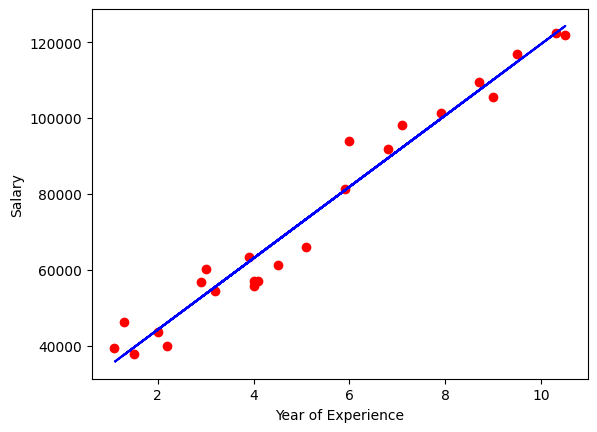

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color = "red")
plt.plot(X_train, model.predict(X_train), color = "blue")
plt.xlabel("Year of Experience")
plt.ylabel("Salary")
plt.show()

- Blue line is a linear line because the model used is linear regression

# Visualizing the test results

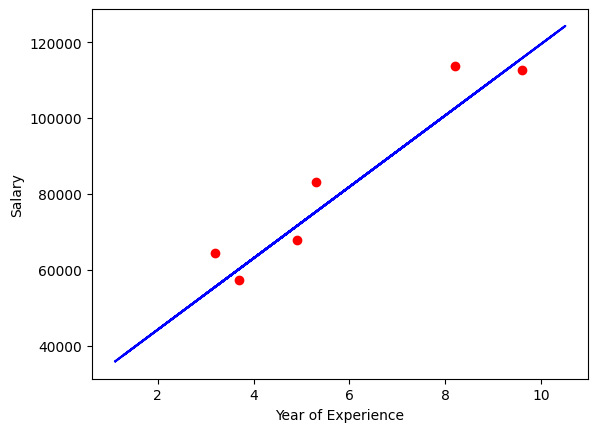

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color = "red")
plt.plot(X_train, model.predict(X_train), color = "blue")
plt.xlabel("Year of Experience")
plt.ylabel("Salary")
plt.show()

### Predict the salary of an employee with 12 years of experience

In [10]:
model.predict([[12]])

/Users/ritumalage/Documents/my_github/knowlegebase/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([138407.36688815])

# Fetching the final regression equation y = wx + b, i.e. the value of w and b which are the model parameters

In [11]:
print("Model Parameters")
print("Weight",model.coef_)
print("Bias", model.intercept_)
print(f"Equation y = {model.coef_[0]} x + {model.intercept_}")

Model Parameters
Weight [9423.81532303]
Bias 25321.583011776813
Equation y = 9423.815323030976 x + 25321.583011776813
